# Learning the digits

You're going to build a model on the digits dataset, a sample dataset that comes pre-loaded with scikit learn. The digits dataset consist of 8x8 pixel handwritten digits from 0 to 9:

<center><img src="images/03.11.png"  style="width: 400px, height: 300px;"/></center>


You want to distinguish between each of the 10 possible digits given an image, so we are dealing with multi-class classification.
The dataset has already been partitioned into X_train, y_train, X_test, and y_test, using 30% of the data as testing data. The labels are already one-hot encoded vectors, so you don't need to use Keras to_categorical() function.

Let's build this new model!

In [1]:
import pandas as pd
import numpy as np
# df = pd.read_csv("dataset/")
X = np.load("dataset/digits_pixels.npy")
y = np.load("dataset/digits_target.npy")
from tensorflow.keras.utils import to_categorical
y = y.reshape(-1,1)
y = to_categorical(y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y , random_state=104,test_size=0.3, shuffle=True)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(1257, 64)
(1257, 10)
(540, 64)
(540, 10)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Instantiate a Sequential model
model = Sequential()

# Input and hidden layer with input_shape, 16 neurons, and relu 
model.add(Dense(16, input_shape = (64,), activation = 'relu'))

# Output layer with 10 neurons (one per digit) and softmax
model.add(Dense(10, activation='softmax'))

# Compile your model
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])



In [3]:
# Test if your model is well assembled by predicting before training
print(model.predict(X_test))

[[7.7850759e-02 1.6196173e-01 7.5008773e-04 ... 8.6414322e-02
  2.9131633e-01 7.7098720e-03]
 [1.7150160e-03 1.9643880e-02 5.6194978e-05 ... 5.0807702e-03
  3.5145521e-02 5.2575629e-02]
 [1.3299841e-08 4.9115658e-01 9.4538592e-08 ... 2.5166067e-09
  5.0856066e-01 8.7627524e-07]
 ...
 [3.0095326e-02 7.6572716e-02 1.6840780e-01 ... 1.5087605e-02
  3.0481216e-02 6.5322048e-03]
 [3.2154433e-03 4.6418822e-01 1.3437258e-05 ... 1.0806758e-02
  1.7060500e-01 2.0922073e-03]
 [1.6160944e-02 2.0020200e-02 2.3095435e-03 ... 8.6603677e-03
  8.6148316e-01 2.9103283e-03]]


# Is the model overfitting?

Let's train the model you just built and plot its learning curve to check out if it's overfitting! You can make use of the loaded function plot_loss() to plot training loss against validation loss, you can get both from the history callback.

In [4]:
import matplotlib.pyplot as plt
def plot_loss(loss,val_loss):
  plt.figure()
  plt.plot(loss)
  plt.plot(val_loss)
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Test'], loc='upper right')
  plt.show()

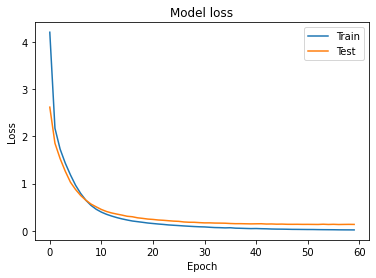

In [5]:
# Train your model for 60 epochs, using X_test and y_test as validation data
h_callback = model.fit(X_train, y_train, epochs = 60,  verbose=0, validation_data = (X_test, y_test)) 

# Extract from the h_callback object loss and val_loss to plot the learning curve
plot_loss(h_callback.history['loss'], h_callback.history['val_loss'])

- This graph doesn't show overfitting but convergence. It looks like the model has learned all it could from the data and it no longer improves. The test loss, although higher than the training loss, is not getting worse, so we aren't overfitting to the training data.

# Do we need more data?

It's time to check whether the digits dataset model you built benefits from more training examples!

In [7]:
def plot_results(train_accs,test_accs):
  plt.plot(training_sizes, train_accs, 'o-', label="Training Accuracy")
  plt.plot(training_sizes, test_accs, 'o-', label="Test Accuracy")
  plt.title('Accuracy vs Number of training samples')
  plt.xlabel('# of training samples')
  plt.ylabel('Accuracy')
  plt.legend(loc="best")
  plt.show()

Epoch 1/50
4/4 [==============================] - 0s 1ms/step - loss: 0.0216 - accuracy: 0.9920
Epoch 2/50
4/4 [==============================] - 0s 1ms/step - loss: 0.0181 - accuracy: 1.0000
Epoch 3/50
4/4 [==============================] - 0s 995us/step - loss: 0.0163 - accuracy: 1.0000
Epoch 4/50
4/4 [==============================] - 0s 1ms/step - loss: 0.0145 - accuracy: 1.0000
Epoch 5/50
4/4 [==============================] - 0s 1ms/step - loss: 0.0133 - accuracy: 1.0000
Epoch 6/50
4/4 [==============================] - 0s 3ms/step - loss: 0.0121 - accuracy: 1.0000
Epoch 7/50
4/4 [==============================] - 0s 739us/step - loss: 0.0111 - accuracy: 1.0000
Epoch 8/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0102 - accuracy: 1.0000
Epoch 9/50
4/4 [==============================] - 0s 3ms/step - loss: 0.0096 - accuracy: 1.0000
Epoch 10/50
4/4 [==============================] - 0s 997us/step - loss: 0.0092 - accuracy: 1.0000
Epoch 11/50
4/4 [================

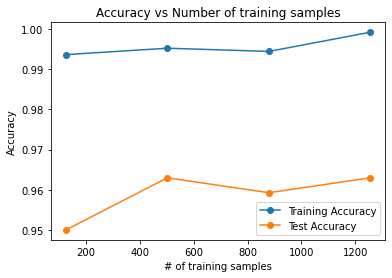

In [8]:
initial_weights = model.get_weights()
training_sizes = np.array([ 125,  502,  879, 1255])
train_accs = []
test_accs = []
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(patience=1)
for size in training_sizes:
  	# Get a fraction of training data (we only care about the training data)
    X_train_frac, y_train_frac = X_train[:size], y_train[:size]

    # Reset the model to the initial weights and train it on the new training data fraction
    model.set_weights(initial_weights)
    model.fit(X_train_frac, y_train_frac, epochs = 50, callbacks = [early_stop])

    # Evaluate and store both: the training data fraction and the complete test set results
    train_accs.append(model.evaluate(X_train, y_train)[1])
    test_accs.append(model.evaluate(X_test, y_test)[1])
    
# Plot train vs test accuracies
plot_results(train_accs, test_accs)

# Different activation functions

The sigmoid(),tanh(), ReLU(), and leaky_ReLU() functions have been defined and ready for you to use. Each function receives an input number X and returns its corresponding Y value.

Which of the statements below is true?

- The `sigmoid()` takes a value of 0.5 when X = 0 whilst `tanh()` takes a value of 0.
- The `leaky_ReLU()` takes a value of -0.01 when X = -1 whilst `ReLU()` takes a value of 0.

# Comparing activation functions

Comparing activation functions involves a bit of coding, but nothing you can't do!

You will try out different activation functions on the multi-label model you built for your farm irrigation machine in chapter 2. The function get_model('relu') returns a copy of this model and applies the 'relu' activation function to its hidden layer.

You will loop through several activation functions, generate a new model for each and train it. By storing the history callback in a dictionary you will be able to visualize which activation function performed best in the next exercise!

In [14]:
def get_model(act_function):
  # Instantiate a Sequential model
  model = Sequential()
  model.add(Dense(16, input_shape = (64,), activation = act_function))
  model.add(Dense(10, activation='softmax'))
  model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
  return model

In [16]:
# Activation functions to try
activations = ['relu', 'sigmoid', 'tanh']

# Loop over the activation functions
activation_results = {}

for act in activations:
  # Get a new model with the current activation
  model = get_model(act)
  # Fit the model and store the history results
  h_callback = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=0)
  activation_results[act] = h_callback

# Comparing activation functions II

What you coded in the previous exercise has been executed to obtain theactivation_results variable, this time 100 epochs were used instead of 20. This way you will have more epochs to further compare how the training evolves per activation function.

In [28]:
val_loss_per_function = {}
val_acc_per_function = {}
# val_loss_per_function = [val_loss_per_function[k] = activation_results[k]['val_loss'] 
for k,v in activation_results.items():
    val_loss_per_function[k] = activation_results[k].history['val_loss'] 
for k,v in activation_results.items():
    val_acc_per_function[k] = activation_results[k].history['val_accuracy'] 
# activation_results.keys()
    

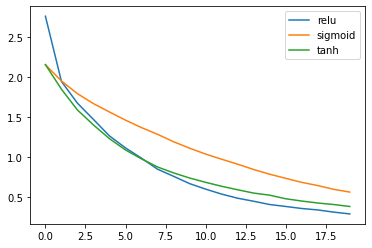

In [29]:

# Create a dataframe from val_loss_per_function
val_loss= pd.DataFrame(val_loss_per_function)

# Call plot on the dataframe
val_loss.plot()
plt.show()


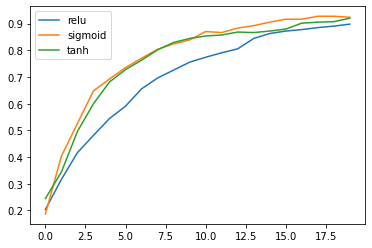

In [30]:

# Create a dataframe from val_acc_per_function
val_acc = pd.DataFrame(val_acc_per_function)

# Call plot on the dataframe
val_acc.plot()
plt.show()

# Changing batch sizes

You've seen models are usually trained in batches of a fixed size. The smaller a batch size, the more weight updates per epoch, but at a cost of a more unstable gradient descent. Specially if the batch size is too small and it's not representative of the entire training set.

Let's see how different batch sizes affect the accuracy of a simple binary classification model that separates red from blue dots.

You'll use a batch size of one, updating the weights once per sample in your training set for each epoch. Then you will use the entire dataset, updating the weights only once per epoch.

In [32]:
# Get a fresh new model with get_model
model = get_model(act_function='relu')

# Train your model for 5 epochs with a batch size of 1
model.fit(X_train, y_train, epochs=5, batch_size=1)
print("\n The accuracy when using a batch of size 1 is: ",
      model.evaluate(X_test, y_test)[1])

Epoch 1/5
1257/1257 [==============================] - 2s 2ms/step - loss: 2.0310 - accuracy: 0.4901
Epoch 2/5
1257/1257 [==============================] - 1s 997us/step - loss: 0.5666 - accuracy: 0.8250
Epoch 3/5
1257/1257 [==============================] - 1s 584us/step - loss: 0.3260 - accuracy: 0.9109
Epoch 4/5
1257/1257 [==============================] - 1s 503us/step - loss: 0.2430 - accuracy: 0.9268
Epoch 5/5
17/17 [==============================] - 0s 1ms/step - loss: 0.2722 - accuracy: 0.9111

 The accuracy when using a batch of size 1 is:  0.9111111164093018


In [33]:
model = get_model(act_function='relu')

# Fit your model for 5 epochs with a batch of size the training set
model.fit(X_train, y_train, epochs=5, batch_size=len(X_train))
print("\n The accuracy when using the whole training set as batch-size was: ",
      model.evaluate(X_test, y_test)[1])

Epoch 1/5
1/1 [==============================] - 0s 3ms/step - loss: 9.5160 - accuracy: 0.0493
Epoch 2/5
1/1 [==============================] - 0s 2ms/step - loss: 9.1444 - accuracy: 0.0501
Epoch 3/5
1/1 [==============================] - 0s 2ms/step - loss: 8.7817 - accuracy: 0.0525
Epoch 4/5
1/1 [==============================] - 0s 2ms/step - loss: 8.4266 - accuracy: 0.0549
Epoch 5/5
17/17 [==============================] - 0s 1ms/step - loss: 7.5298 - accuracy: 0.0593

 The accuracy when using the whole training set as batch-size was:  0.05925925821065903


# Batch normalizing a familiar model

A multi-class classification problem that you solved using softmax and 10 neurons in your output layer.

You will now build a new deeper model consisting of 3 hidden layers of 50 neurons each, using batch normalization in between layers. The kernel_initializer parameter is used to initialize weights in a similar way.

In [34]:
# Import batch normalization from keras layers
from tensorflow.keras.layers import BatchNormalization

# Build your deep network
batchnorm_model = Sequential()
batchnorm_model.add(Dense(50, input_shape=(64,), activation='relu', kernel_initializer='normal'))
batchnorm_model.add(BatchNormalization())
batchnorm_model.add(Dense(50, activation='relu', kernel_initializer='normal'))
batchnorm_model.add(BatchNormalization())
batchnorm_model.add(Dense(50, activation='relu', kernel_initializer='normal'))
batchnorm_model.add(BatchNormalization())
batchnorm_model.add(Dense(10, activation='softmax', kernel_initializer='normal'))

# Compile your model with sgd
batchnorm_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

# Batch normalization effects

Batch normalization tends to increase the learning speed of our models and make their learning curves more stable. Let's see how two identical models with and without batch normalization compare.

The model you just built batchnorm_model is loaded for you to use. An exact copy of it without batch normalization: standard_model, is available as well. You can check their summary() in the console. X_train, y_train, X_test, and y_test are also loaded so that you can train both models.

In [35]:
def compare_histories_acc(h1,h2):
  plt.plot(h1.history['accuracy'])
  plt.plot(h1.history['val_accuracy'])
  plt.plot(h2.history['accuracy'])
  plt.plot(h2.history['val_accuracy'])
  plt.title("Batch Normalization Effects")
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Train', 'Test', 'Train with Batch Normalization', 'Test with Batch Normalization'], loc='best')
  plt.show()

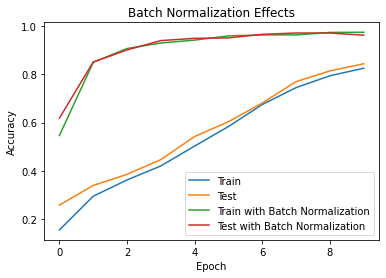

In [36]:
standard_model = model
# Train your standard model, storing its history callback
h1_callback = standard_model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=10, verbose=0)

# Train the batch normalized model you recently built, store its history callback
h2_callback = batchnorm_model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=10, verbose=0)

# Call compare_histories_acc passing in both model histories
compare_histories_acc(h1_callback, h2_callback)

# Preparing a model for tuning

Let's tune the hyperparameters of a binary classification model that does well classifying the breast cancer dataset.

You've seen that the first step to turn a model into a sklearn estimator is to build a function that creates it. The definition of this function is important since hyperparameter tuning is carried out by varying the arguments your function receives.

Build a simple create_model() function that receives both a learning rate and an activation function as arguments. The Adam optimizer has been imported as an object from tensorflow.keras.optimizers so that you can also change its learning rate parameter.

In [42]:
from tensorflow.keras.optimizers import Adam
# Creates a model given an activation and learning rate
def create_model(learning_rate, activation):
  
  	# Create an Adam optimizer with the given learning rate
  	opt = Adam(lr = learning_rate)
  	
  	# Create your binary classification model  
  	model = Sequential()
  	model.add(Dense(128, input_shape = (4,), activation = activation))
  	model.add(Dense(256, activation = activation))
  	model.add(Dense(1, activation = 'sigmoid'))
  	
  	# Compile your model with your optimizer, loss, and metrics
  	model.compile(optimizer = opt, loss = 'binary_cross_entropy', metrics = ['accuracy'])
  	return model

# Tuning the model parameters

Since fitting the RandomizedSearchCV object would take too long, the results you'd get are printed in the show_results() function. You could try random_search.fit(X,y) in the console yourself to check it does work after you have built everything else, but you will probably timeout the exercise (so copy your code first if you try this or you can lose your progress!).

In [38]:
# Import KerasClassifier from tensorflow.keras scikit learn wrappers
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import  RandomizedSearchCV, KFold

# Create a KerasClassifier
model = KerasClassifier(build_fn = create_model)

# Define the parameters to try out
params = {'activation': ['relu' , 'tanh'], 'batch_size': [ 32, 128, 256], 
          'epochs': [50, 100, 200], 'learning_rate': [0.1, 0.01,  0.001]}

# Create a randomize search cv object passing in the parameters to try
random_search = RandomizedSearchCV(model, param_distributions = params, cv = KFold(3))

# Running thiswould start the search,but it takes too long! 
# random_search.fit(X,y)

# Training with cross-validation

ime to train your model with the best parameters found: 0.001 for the learning rate, 50 epochs, a 128 batch_size and relu activations.

The create_model() function from the previous exercise is ready for you to use. X and y are loaded as features and labels.

Use the best values found for your model when creating your KerasClassifier object so that they are used when performing cross_validation.

End this chapter by training an awesome tuned model on the breast cancer dataset!

In [47]:
df = pd.read_csv("dataset/banknotes.csv")
X = df.drop("class", axis=1)
y = df["class"]
print(X.shape)
print(y.shape)

df.head()


(1372, 4)
(1372,)


,variace,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [49]:
# # Import KerasClassifier from tensorflow.keras wrappers
# from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
# from sklearn.model_selection import cross_val_score

# # Create a KerasClassifier
# model = KerasClassifier(build_fn = create_model(learning_rate = 0.001, activation = 'relu'), epochs = 50, 
#              batch_size = 32, verbose = 0)

# # Calculate the accuracy score for each fold
# kfolds = cross_val_score(model, X, y, cv = 3)

# # Print the mean accuracy
# print('The mean accuracy was:', kfolds.mean())

# # Print the accuracy standard deviation
# print('With a standard deviation of:', kfolds.std())